execute in terminal: jupyter nbconvert --to html --execute --template pj retail_sales_analysis.ipynb

## Part 1: Introduction

Retail businesses generate large volumes of sales data that can be analyzed to identify customer demand patterns, seasonal trends, and operational insights. Accurate sales forecasting is important for supporting inventory management, staffing decisions, promotional planning, and overall business operations.

This project analyzes historical retail sales data from the Rossmann Store Sales dataset to explore key factors influencing sales performance and develop predictive forecasting models. Exploratory data analysis was conducted to examine trends, seasonality, promotional effects, and customer behavior patterns across retail stores.

Multiple regression and machine learning techniques were implemented using Python and scikit-learn to evaluate sales prediction performance. In addition, an interactive Streamlit forecasting dashboard was developed using Holt-Winters Exponential Smoothing to generate store-level sales forecasts and visualize future demand trends.

The project demonstrates how data analytics and forecasting techniques can support operational planning and data-driven decision-making in retail and supply chain environments.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
train = pd.read_csv("../data/train.csv")

In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


## Part 2: Data Cleaning 

The dataset was cleaned and preprocessed to improve
data quality and prepare the data for exploratory
analysis, predictive modeling, and forecasting.

Key preprocessing steps included:
- handling missing values
- converting date variables
- engineering time-based features
- filtering closed-store observations
- encoding categorical variables

In [5]:
train.isnull().sum() #check for missing values

train = train.dropna() #remove rows with missing values

train["Date"] = pd.to_datetime(train["Date"]) #convert Date to datetime type 

The Date column was converted into datetime format
to enable time-series analysis and extraction of
calendar-based features.

In [6]:
#Feature Engineering 

# Additional time-based features were created to capture
# potential seasonal and operational sales patterns.


train["Year"] = train["Date"].dt.year #extract year 
train["Month"] = train["Date"].dt.month #extract month
train["Day"] = train["Date"].dt.day #extract day
train["DayOfWeek"] = train["Date"].dt.dayofweek #extract day of week 
train["WeekOfYear"] = train["Date"].dt.isocalendar().week #extract ISO week number

#create weekend indicator 
train["IsWeekend"] = train["DayOfWeek"].isin([5,6]).astype(int)


train = train[train["Open"] == 1] #remove closed stores
train = train[train["Sales"] > 0] #remove zero-sales observations

Closed-store observations and zero-sales entries
were removed to avoid structural distortions in
sales analysis and forecasting behavior.

The analysis therefore focuses on operational
sales performance during active store periods.

In [7]:
train["StateHoliday"] = train["StateHoliday"].astype(str) #convert StateHoliday to string type

#one-hot encode holiday categories
train = pd.get_dummies(
    train,
    columns=["StateHoliday"],
    drop_first=True
)

Categorical holiday indicators were converted into
dummy variables to support regression analysis and
machine learning model compatibility.

## Part 3: Exploratory Data Analysis

### Daily Sales Trend

Daily retail sales were aggregated across all operating stores to examine overall sales behavior over time. This visualization helps identify long-term trends, recurring seasonal patterns, and periods of unusually high or low sales activity.

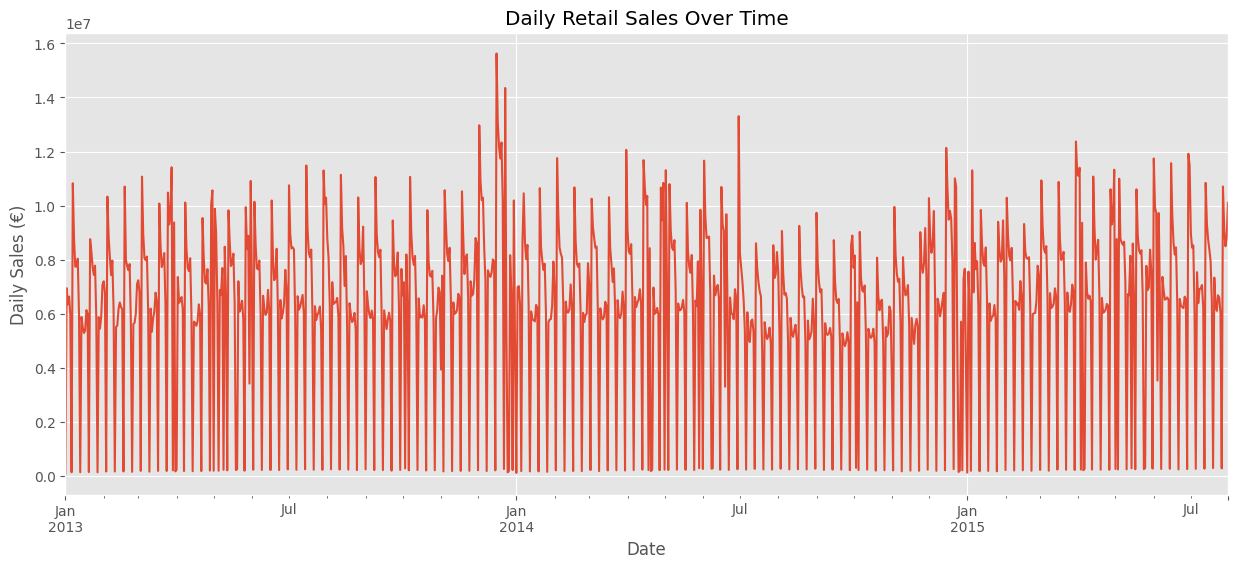

In [8]:
daily_sales = train.groupby("Date")["Sales"].sum()

plt.figure(figsize=(15,6))

daily_sales.plot()

plt.title("Daily Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Sales (€)")

plt.show()

The daily sales trend demonstrates recurring cyclical fluctuations, suggesting strong seasonal and weekly sales patterns within the retail dataset. Several sharp sales peaks are also observed, which may be associated with promotional campaigns, holidays, or periods of increased customer demand.

The consistent variability in sales activity indicates that seasonality and temporal factors are likely important predictors for forecasting and predictive modeling.

### Monthly Sales Trends

Average monthly sales were analyzed to identify broader seasonal demand patterns across the retail dataset. Understanding monthly sales fluctuations may provide insights into peak business periods and operational demand cycles.

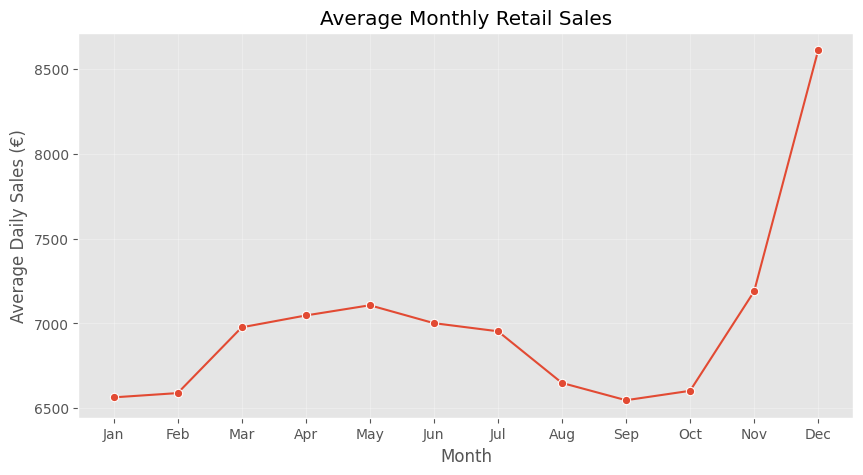

In [9]:
monthly_sales = train.groupby("Month")["Sales"].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.xticks(
    ticks=range(1,13),
    labels=month_labels
)

plt.title("Average Monthly Retail Sales")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales (€)")
plt.grid(alpha=0.3)

plt.show()

Monthly sales trends indicate noticeable seasonality within the retail dataset. Sales activity generally increases toward the end of the year, with December showing the highest average sales levels. This pattern may be associated with holiday shopping periods and increased customer demand during year-end promotional seasons.

Lower average sales levels were observed during several mid-year months, suggesting potential seasonal slowdowns in retail activity.

Monthly sales trends reveal recurring seasonal patterns, suggesting that certain periods experience consistently stronger customer demand.

### Promotion Impact

The relationship between promotional campaigns and retail sales performance was analyzed to evaluate the effectiveness of promotions in driving customer demand and increasing revenue.

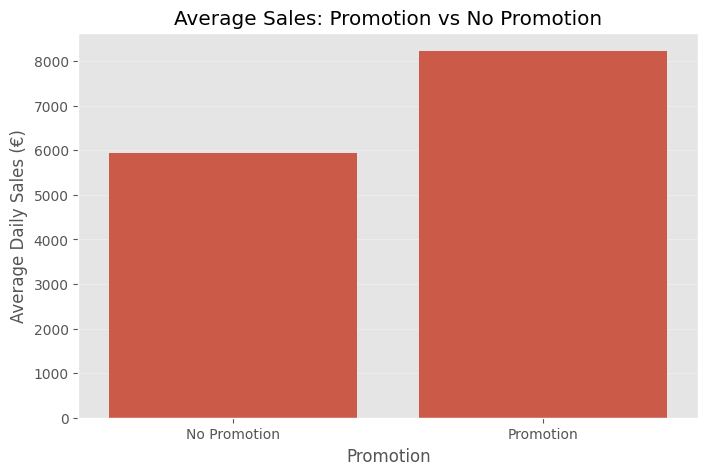

In [10]:
promo_sales = train.groupby("Promo")["Sales"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=promo_sales.index,
    y=promo_sales.values
)

plt.xticks(
    ticks=[0,1],
    labels=["No Promotion", "Promotion"]
)

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Daily Sales (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

Stores running promotional campaigns generated noticeably higher average sales compared to non-promotional periods. This suggests that promotions have a significant positive impact on retail sales performance and customer purchasing activity.

The findings indicate that promotional strategies may play an important role in increasing short-term demand and supporting revenue growth. Such insights may also support operational planning decisions related to inventory allocation and staffing during promotional periods.

### Holiday Impact 

Average sales levels during school holiday periods were analyzed to evaluate whether holiday seasons influence customer purchasing behavior and retail demand patterns.

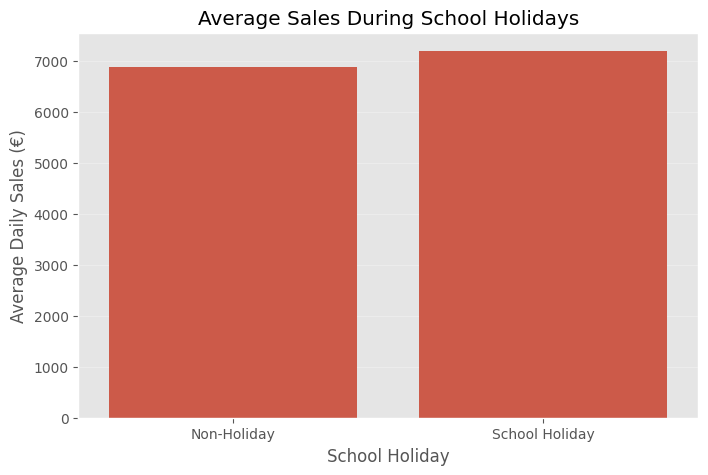

In [11]:
holiday_sales = train.groupby("SchoolHoliday")["Sales"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.xticks(
    ticks=[0,1],
    labels=["Non-Holiday", "School Holiday"]
)

plt.title("Average Sales During School Holidays")
plt.xlabel("School Holiday")
plt.ylabel("Average Daily Sales (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

Average sales during school holiday periods were slightly higher compared to non-holiday periods, suggesting that holiday seasons may contribute to increased retail activity and customer demand.

However, the difference appears relatively moderate compared to the impact observed from promotional campaigns, indicating that promotions may have a stronger influence on sales performance than school holiday effects alone.

### Customer Traffic vs Sales

The relationship between customer traffic and retail sales was analyzed to evaluate whether higher customer volumes are associated with increased sales performance.

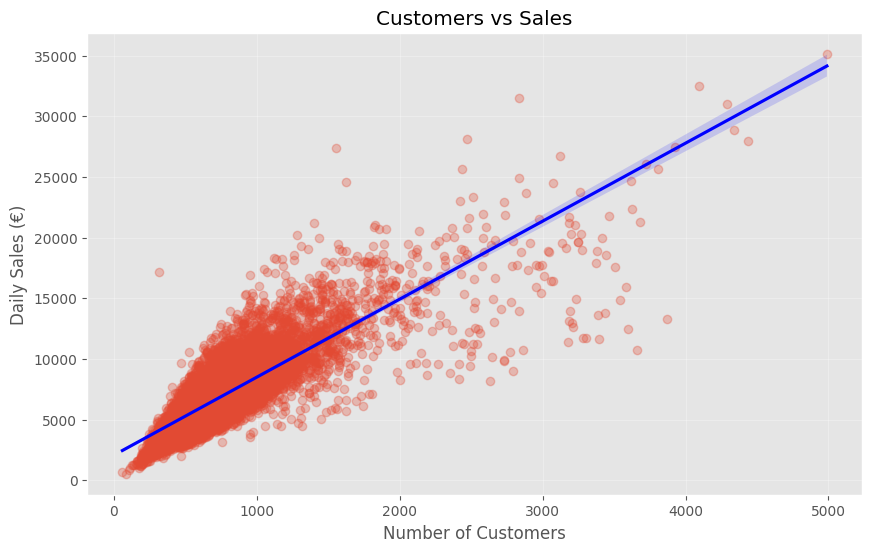

In [30]:
# Sample a subset of the dataset for faster visualization

sampled_train = train.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.regplot(
    data=sampled_train,
    x="Customers",
    y="Sales",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"blue"}
)

plt.title("Customers vs Sales")

plt.xlabel("Number of Customers")

plt.ylabel("Daily Sales (€)")

plt.grid(alpha=0.3)

plt.show()

The scatterplot demonstrates a strong positive relationship between customer traffic and sales performance. Stores with higher customer counts generally generate higher sales revenue, suggesting that customer traffic is an important predictor of retail sales.

The upward trend observed in the data supports the inclusion of customer-related variables in subsequent regression and predictive modeling analyses.

### Correlation Analysis

A correlation heatmap was generated to examine linear relationships between key retail sales variables. Correlation analysis helps identify variables that may strongly influence sales performance and provides useful insights for subsequent regression and predictive modeling.

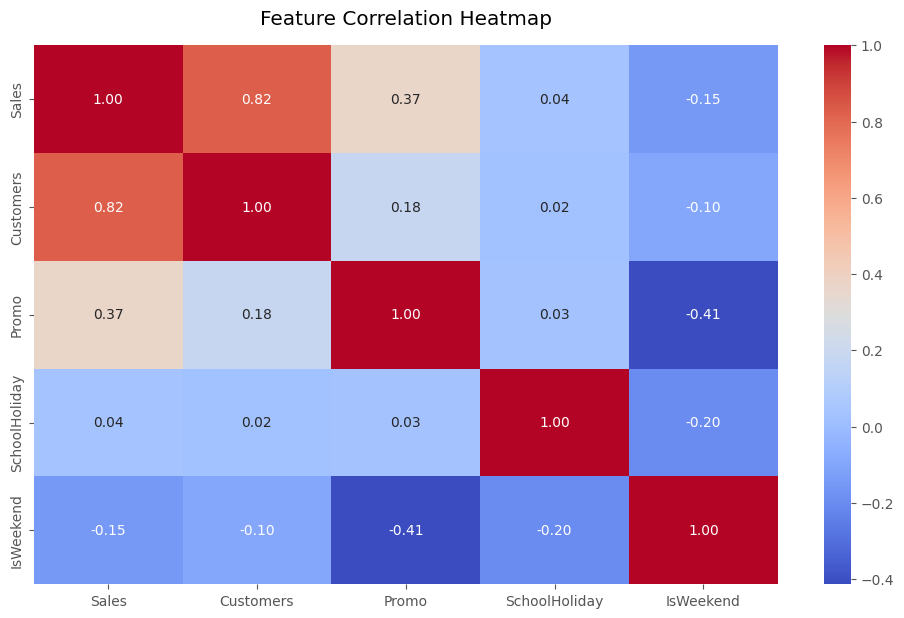

In [13]:
plt.figure(figsize=(12,7))

sns.heatmap(
    train[
        [
            "Sales",
            "Customers",
            "Promo",
            "SchoolHoliday",
            "IsWeekend"
        ]
    ].corr(),
    annot=True,
    fmt = ".2f",
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Heatmap",
    pad=15
)

plt.show()

The heatmap indicates a strong positive correlation between customer traffic and sales performance, suggesting that customer volume is a major driver of retail sales. Promotional activity also demonstrates a moderate positive relationship with sales, supporting earlier findings that promotions contribute to increased customer demand.

In contrast, school holiday effects appear relatively weak, indicating that holiday periods alone may not significantly influence overall sales performance. Weekend indicators show a slight negative relationship with sales, suggesting possible operational or customer traffic differences during weekends.

The correlation analysis supports the inclusion of customer traffic and promotional variables in subsequent regression and machine learning models.

### Sales Distribution Analysis

The distribution of retail sales values was analyzed to examine the overall spread, concentration, and variability of sales observations within the dataset. Understanding the distribution of sales data is useful for identifying skewness, outliers, and potential modeling considerations.

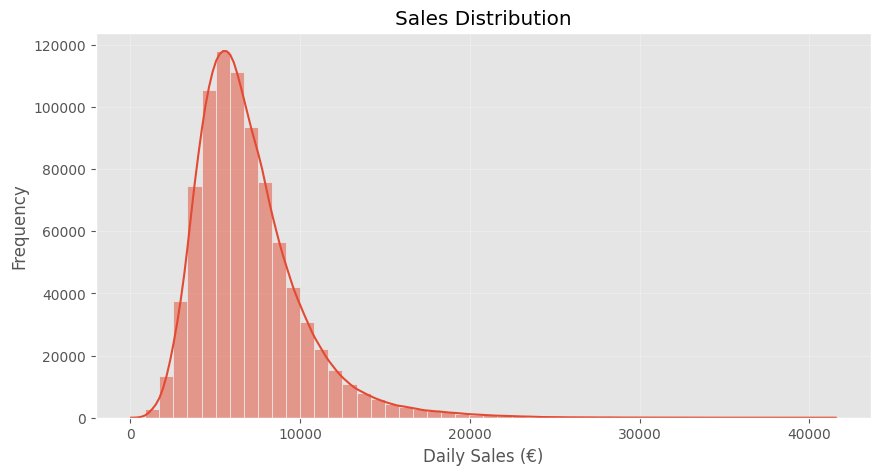

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["Sales"],
    bins=50,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Daily Sales (€)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

The sales distribution appears positively skewed, with most sales observations concentrated within lower to moderate sales ranges and a smaller number of observations exhibiting very high sales values.

The presence of a long right tail suggests that certain periods or stores experience unusually high sales activity, potentially due to promotions, seasonal demand spikes, or other operational factors. This indicates that the dataset contains variability and outlier behavior that may influence regression and predictive modeling performance.

## Part 4: Regression and Predictive Modeling

Regression and machine learning models were developed to predict retail sales performance using customer, promotional, holiday, and seasonal variables. The objective of this section is to evaluate how different predictive modeling techniques capture sales behavior and identify the variables most strongly associated with retail sales performance.

Three predictive approaches were implemented:
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

Model performance was evaluated using common regression metrics including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Feature Selection

The target variable for prediction was retail sales performance, while customer traffic, promotional activity, holiday indicators, and seasonal calendar variables were selected as predictive features based on earlier exploratory analysis findings.

In [16]:
y = train["Sales"] #target variable

#predictor variables
X = train[
    [
        "Customers",
        "Promo",
        "SchoolHoliday",
        "DayOfWeek",
        "Month",
        "IsWeekend"
    ]
]

### Train-Test Split

The dataset was divided into training and testing subsets to evaluate model performance on unseen data. The training data was used to fit predictive models, while the testing data was used to assess forecasting accuracy and generalization performance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.2,
    random_state=42
)

# 80% of the data was used for training
# 20% of the data was used for testing

### Model 1: Linear Regression

A multiple linear regression model was implemented as a baseline predictive model to estimate the relationship between retail sales and the selected predictor variables.

Linear regression provides an interpretable approach for evaluating how customer traffic, promotions, and seasonal factors influence sales performance.

In [18]:
# Initialize Linear Regression model
lr_model = LinearRegression()

# Train model on training data
lr_model.fit(X_train, y_train)

# Generate predictions on test data
lr_predictions = lr_model.predict(X_test)

#### Model Evaluation

The performance of the linear regression model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

- MAE measures the average absolute prediction error.
- RMSE penalizes larger prediction errors more heavily.
- R² score measures the proportion of sales variability explained by the model.

In [19]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)


print("Linear Regression Performance")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Performance
MAE: 1150.349489486357
RMSE: 1603.3929830500006
R2 Score: 0.7335767224906748


The linear regression model achieved an R² score of approximately 0.73, indicating that the model explains a substantial proportion of variability in retail sales performance.

The relatively moderate MAE and RMSE values suggest that the model is capable of generating reasonably accurate sales predictions, although some prediction error remains due to variability and nonlinear behavior within the retail sales data.

#### Coefficient Interpretation

Linear regression coefficients were analyzed to evaluate the direction and relative magnitude of relationships between predictor variables and retail sales performance.

In [20]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

# Round coefficients
coefficients["Coefficient"] = (
    coefficients["Coefficient"]
    .round(2)
)

# Sort by coefficient value
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,Promo,1461.41
5,IsWeekend,656.43
2,SchoolHoliday,102.77
4,Month,28.38
0,Customers,6.02
3,DayOfWeek,-155.70


The coefficient analysis indicates that promotional activity has the strongest positive relationship with retail sales performance among the selected predictor variables. The results suggest that stores running promotions are associated with substantially higher sales levels compared to non-promotional periods.

Weekend periods also demonstrate a positive relationship with sales performance, while customer traffic contributes positively to sales growth as expected. The positive customer coefficient reinforces earlier exploratory analysis findings that higher customer volumes are strongly associated with increased retail sales.

In contrast, the negative coefficient for DayOfWeek suggests that sales performance may vary across different operational weekdays. School holiday and monthly seasonal variables demonstrate comparatively smaller effects within the linear regression model.

Overall, the coefficient analysis highlights the importance of customer demand behavior and promotional strategies in influencing retail sales performance.

### Model 2: Decision Tree Regression

A Decision Tree Regressor was implemented to capture nonlinear relationships and interaction effects between predictor variables and retail sales performance.

Unlike linear regression, decision trees are capable of modeling more complex decision boundaries and variable interactions within the dataset.

In [21]:
# Initialize Decision Tree model
dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Generate predictions
dt_predictions = dt_model.predict(X_test)

#### Model Evaluation

The Decision Tree model was evaluated using MAE, RMSE, and R² score to assess predictive performance on unseen testing data.

In [22]:
# Calculate evaluation metrics

dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_predictions
    )
)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

# Display performance

print("Decision Tree Performance")

print(f"MAE: {dt_mae:.2f}")

print(f"RMSE: {dt_rmse:.2f}")

print(f"R² Score: {dt_r2:.4f}")

Decision Tree Performance
MAE: 1063.56
RMSE: 1471.03
R² Score: 0.7757


The Decision Tree Regressor achieved stronger predictive performance compared to the linear regression model, as indicated by lower MAE and RMSE values and a higher R² score.

This suggests that the decision tree was better able to capture nonlinear relationships and interaction effects within the retail sales dataset. The model demonstrates improved flexibility in modeling complex sales behavior patterns compared to linear regression.

However, decision tree models may also be more susceptible to overfitting if model complexity becomes excessively large.

### Model 3: Random Forest Regressor 

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)


rf_predictions = rf_model.predict(X_test)

In [24]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Performance
MAE: 1056.8696063429813
RMSE: 1455.5743203097418
R2 Score: 0.7804360782355073


The Random Forest Regressor achieved the strongest predictive performance among the implemented models, producing the lowest MAE and RMSE values and the highest R² score.

The improved performance suggests that ensemble learning techniques are effective in capturing complex nonlinear relationships and interaction effects within the retail sales dataset. By combining predictions from multiple decision trees, the Random Forest model is able to reduce overfitting and improve overall prediction stability.

These results indicate that ensemble-based machine learning approaches may provide stronger predictive capabilities for retail sales forecasting and operational planning applications.

### Model Comparison

The predictive performance of the implemented regression and machine learning models was compared using MAE, RMSE, and R² score.

Lower MAE and RMSE values indicate stronger prediction accuracy, while higher R² scores indicate better explanatory performance.

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1150.349489,1603.392983,0.733577
1,Decision Tree,1063.555999,1471.031316,0.775748
2,Random Forest,1056.869606,1455.574320,0.780436


Among the evaluated models, the Random Forest Regressor achieved the strongest predictive performance, producing the lowest MAE and RMSE values and the highest R² score.

The results suggest that ensemble-based machine learning methods are effective in capturing the complex nonlinear relationships and variability present within retail sales data. Decision Tree Regression also demonstrated improved predictive flexibility compared to Linear Regression, although Random Forest provided slightly better generalization performance.

Linear Regression remained useful as an interpretable baseline model, while tree-based approaches improved predictive accuracy by modeling more complex sales behavior patterns.

The findings demonstrate that customer traffic, promotions, and seasonal operational patterns significantly influence retail sales forecasting performance.

### Actual vs Predicted Sales (Random Forest)

In [26]:
results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": rf_predictions
})

#create prediction dataframe
#we use random forest 

<br>

#### Actual vs Predicted Scatterplot

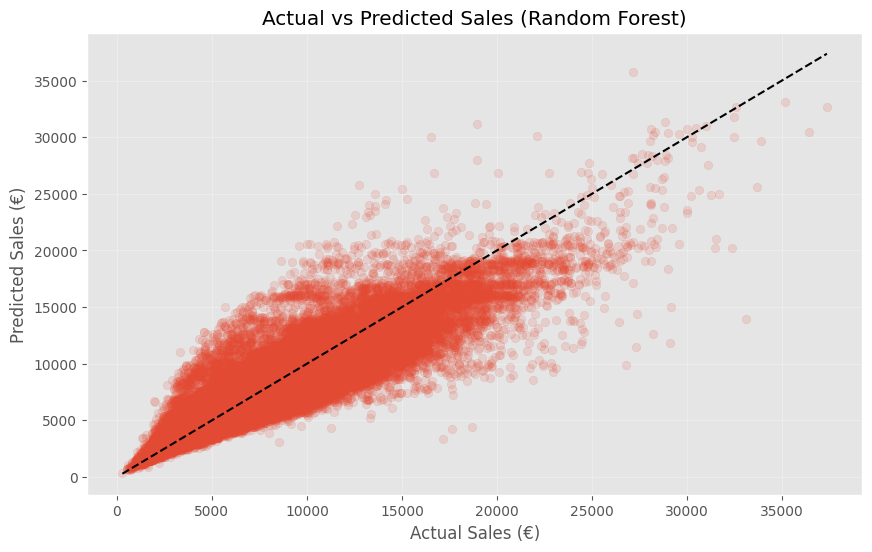

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.15
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color = 'black'
)

plt.xlabel("Actual Sales (€)")

plt.ylabel("Predicted Sales (€)")

plt.title(
    "Actual vs Predicted Sales (Random Forest)"
)

plt.grid(alpha=0.3)

plt.show()

The Actual vs Predicted Sales plot demonstrates that the Random Forest model is generally capable of capturing overall sales behavior and demand patterns within the dataset.

Most predictions follow the overall direction of actual sales values, indicating that the model successfully learned meaningful relationships between the predictor variables and retail sales performance.

Prediction variability increases for extremely high sales observations, suggesting that unusually large sales spikes remain more challenging to predict accurately. This behavior is expected in retail forecasting datasets due to demand variability and operational complexity.

### Feature Importance Analysis

Feature importance analysis was conducted using the Random Forest model to evaluate which variables contributed most strongly to retail sales prediction performance.

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Customers,0.909240
1,Promo,0.055944
3,DayOfWeek,0.020461
4,Month,0.012315
2,SchoolHoliday,0.001255
5,IsWeekend,0.000785


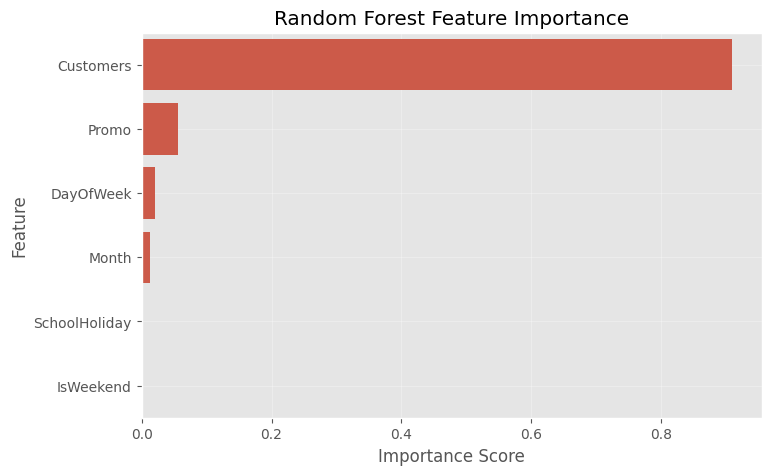

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.grid(alpha=0.3)

plt.show()

Feature importance analysis indicates that customer traffic is the most influential variable in predicting retail sales performance, contributing substantially more predictive power than the other variables included in the model.

Promotional activity also contributes meaningfully to sales prediction, although its impact is considerably smaller compared to customer volume. Seasonal and holiday-related variables demonstrate relatively weaker influence within the Random Forest model.

The findings reinforce earlier exploratory analysis results, suggesting that customer demand behavior and promotional activity are the primary drivers of retail sales performance.

## Part 5: Conclusion and Business Recommendations 

Based on the analysis and forecasting results, several business and operational recommendations can be proposed:

1. Promotion Planning

Promotional campaigns demonstrated a strong positive relationship with retail sales performance. Businesses may leverage targeted promotions during slower sales periods to stimulate customer demand and improve revenue generation.

2. Inventory and Capacity Planning

Sales forecasting models may support inventory allocation and operational capacity planning by identifying expected demand fluctuations across different periods. Improved forecasting can help reduce stock shortages and overstocking risks.

3. Staffing Optimization

Forecasted sales trends may assist workforce scheduling and staffing preparation during anticipated high-demand periods, particularly during promotional events and seasonal peaks.

4. Demand Monitoring

Customer traffic was identified as the strongest predictor of retail sales performance. Monitoring customer activity and foot traffic trends may therefore provide valuable early indicators of future sales behavior.

5. Seasonal Preparation

The analysis identified recurring seasonal demand patterns within the retail dataset. Businesses may use these insights to prepare inventory, logistics, and operational resources ahead of peak demand periods.

### Conclusion

This project analyzed historical retail sales data to identify sales trends, seasonal demand patterns, promotional effects, and customer behavior relationships within the Rossmann retail dataset.

Exploratory data analysis revealed that customer traffic and promotional activity were strongly associated with retail sales performance, while seasonal and calendar-based patterns also influenced demand fluctuations across different periods.

Multiple predictive modeling techniques were implemented to forecast retail sales performance, including Linear Regression, Decision Tree Regression, and Random Forest Regression. Among the evaluated models, the Random Forest Regressor achieved the strongest predictive performance, demonstrating the effectiveness of ensemble-based machine learning approaches for capturing complex retail sales behavior.

## Part 6: Interactive Forecasting Dashboard

An interactive Streamlit dashboard was developed to provide store-level retail sales forecasting and visualization capabilities using Holt-Winters Exponential Smoothing.

The dashboard enables:
- dynamic store selection
- adjustable forecast horizons
- interactive sales trend visualization
- operational forecasting support